In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
training_set = pd.read_csv('./data/titanic.csv')
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
training_set.describe(include=['O'])  # descriptive statistics

/var/folders/4d/1d5j55lj60v45fpt1wk0gwm80000gn/T/ipykernel_2024/682754479.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  training_set.describe(include=['O'])  # descriptive statistics


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


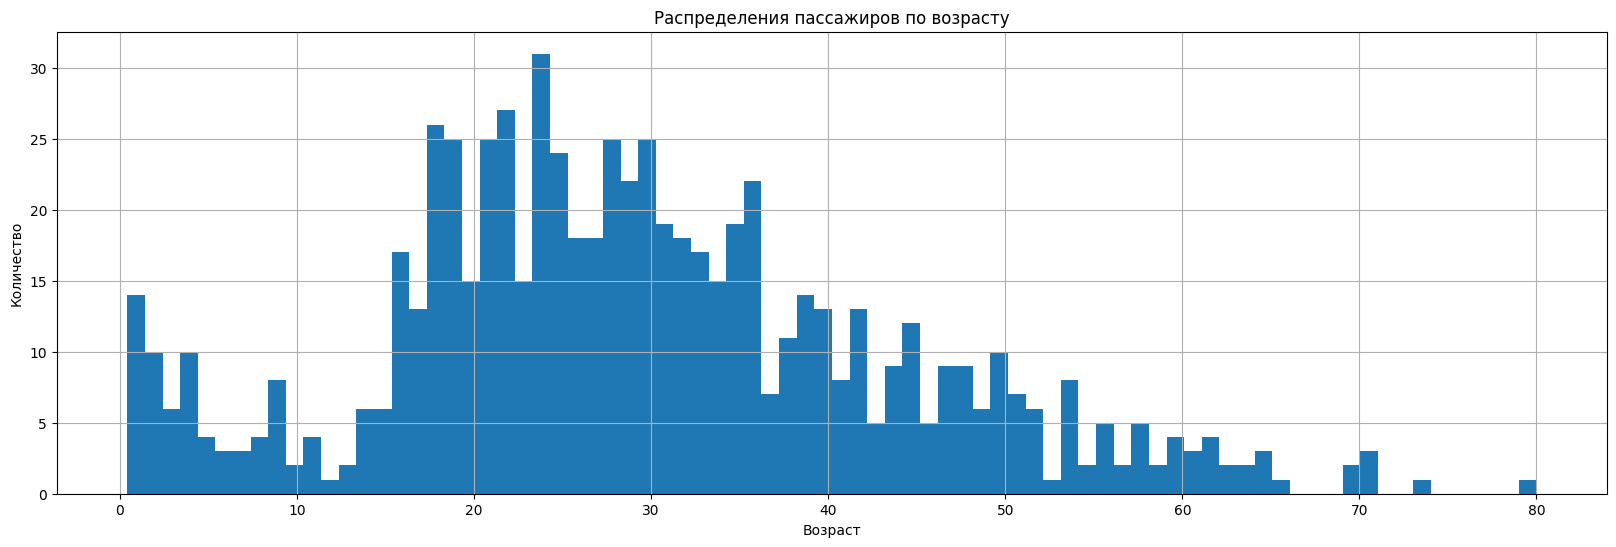

In [5]:
def custom_hist(training_set, title,  xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

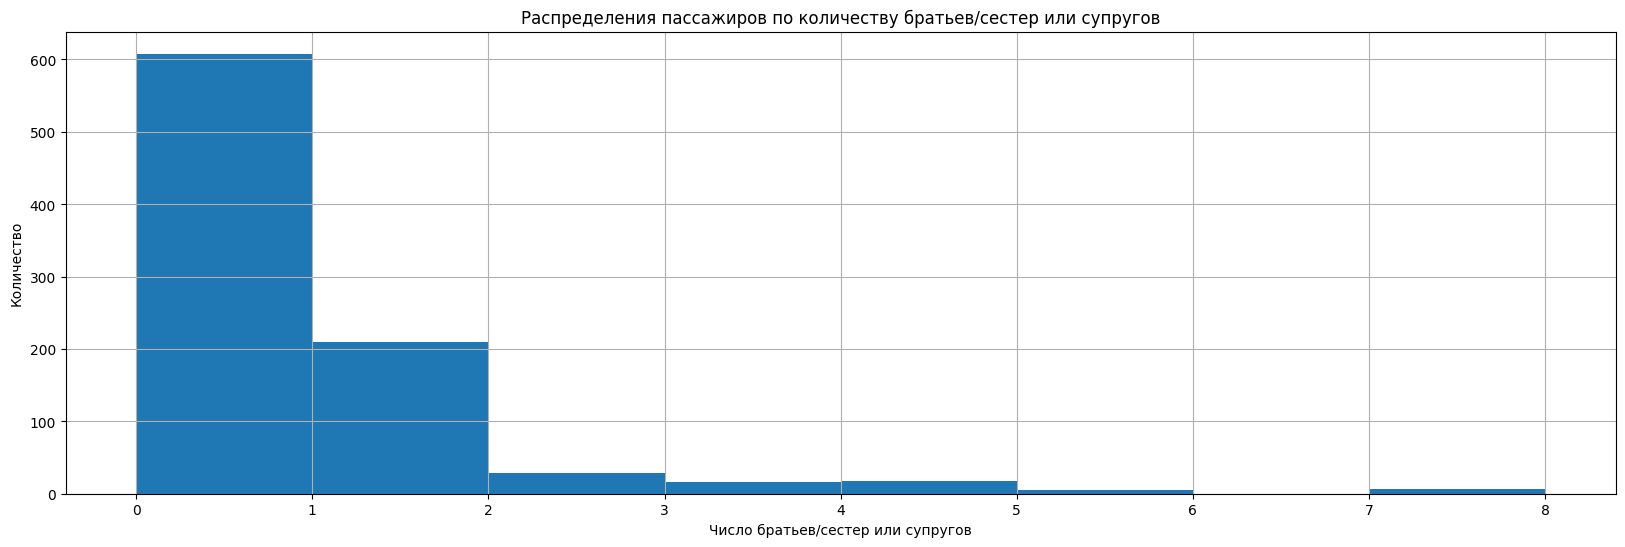

In [6]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов', 
  'Число братьев/сестер или супругов')

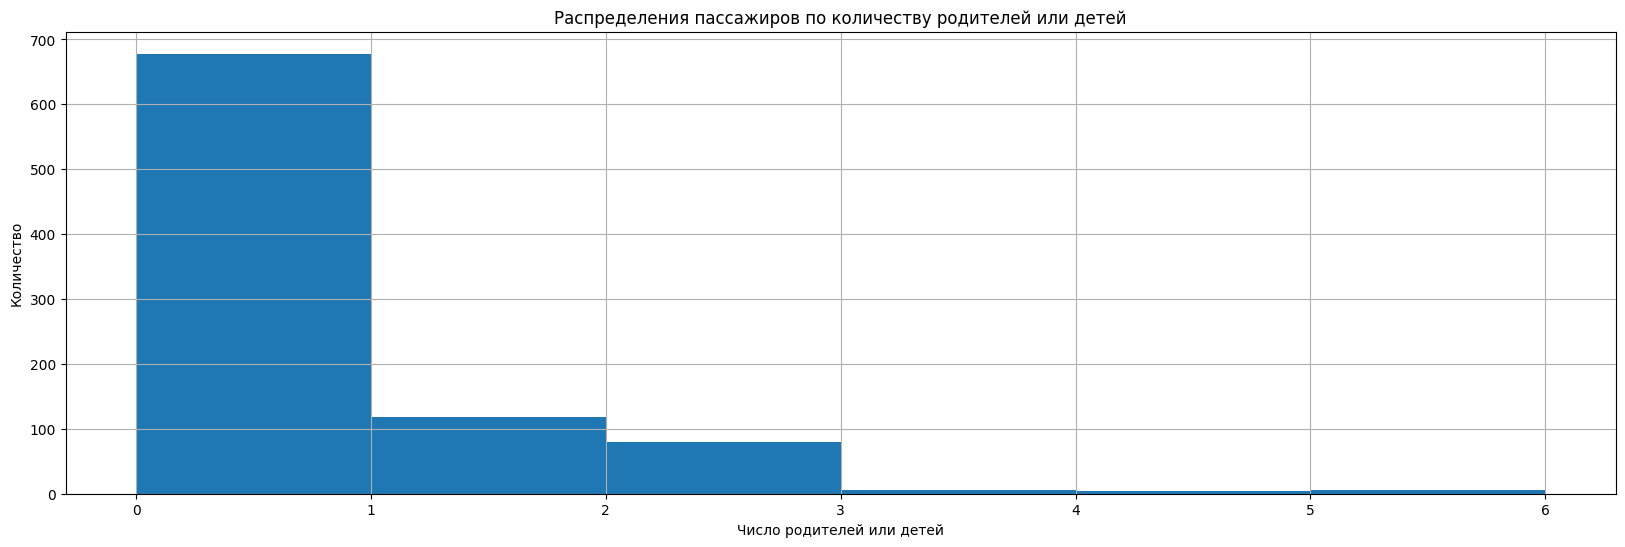

In [7]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей', 
  'Число родителей или детей')

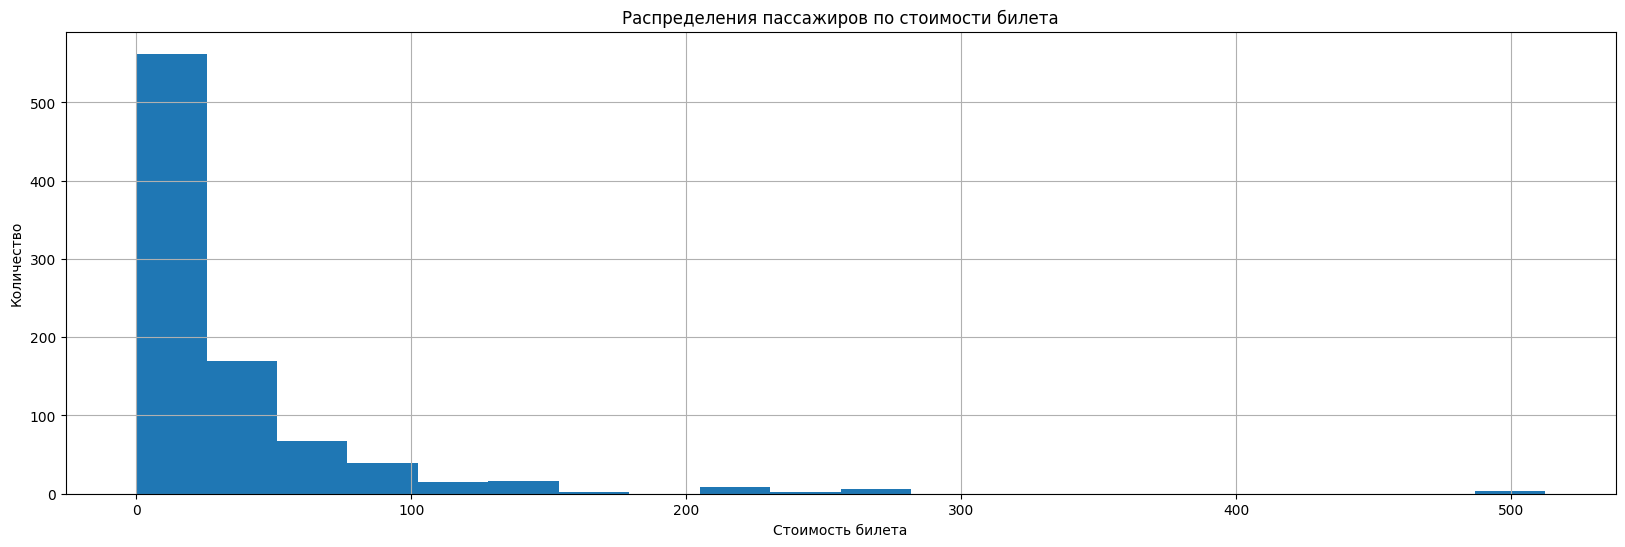

In [8]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета', 
  'Стоимость билета', bins=20)

<Axes: ylabel='Frequency'>

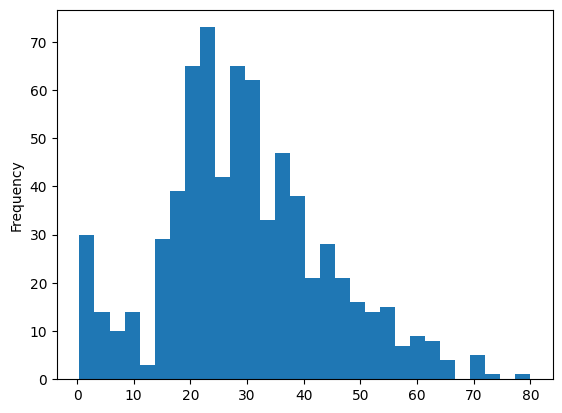

In [9]:
training_set['Age'].plot.hist(bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

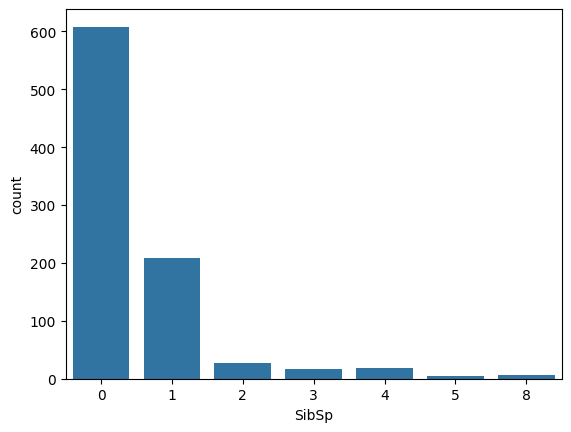

In [10]:
sns.countplot(x='SibSp', data=training_set)

In [11]:
training_set['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

<Axes: >

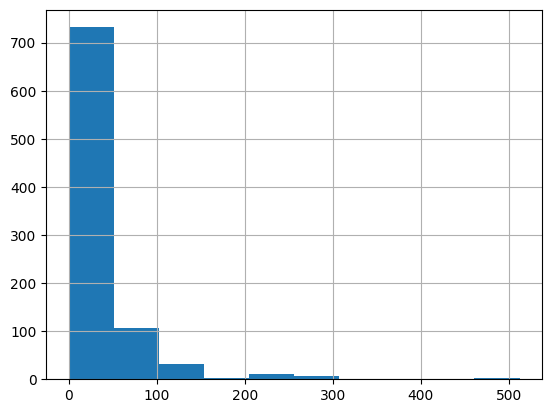

In [12]:
training_set['Fare'].hist()

<Axes: >

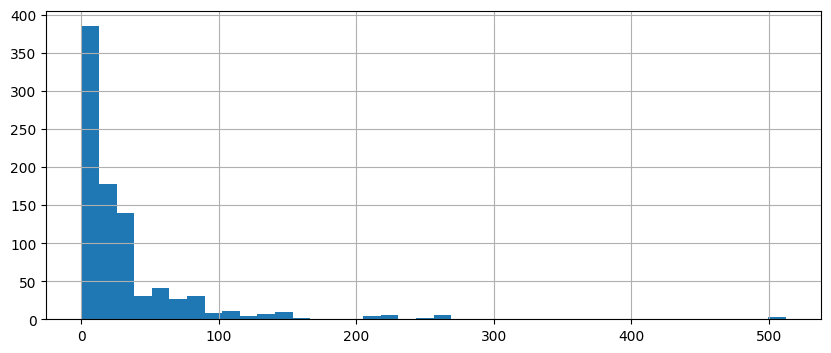

In [13]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

<Axes: xlabel='Survived', ylabel='count'>

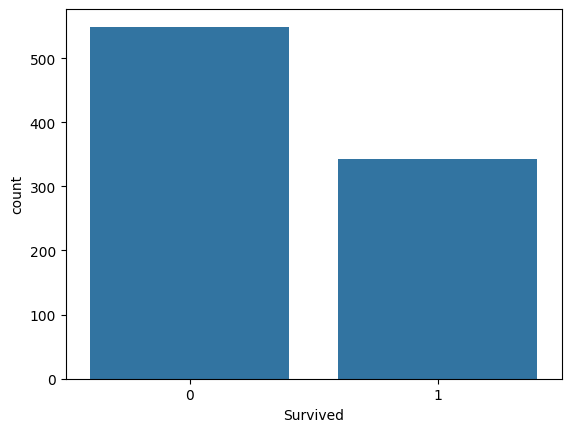

In [14]:
sns.countplot(x='Survived', data=training_set)

<Axes: xlabel='Survived', ylabel='count'>

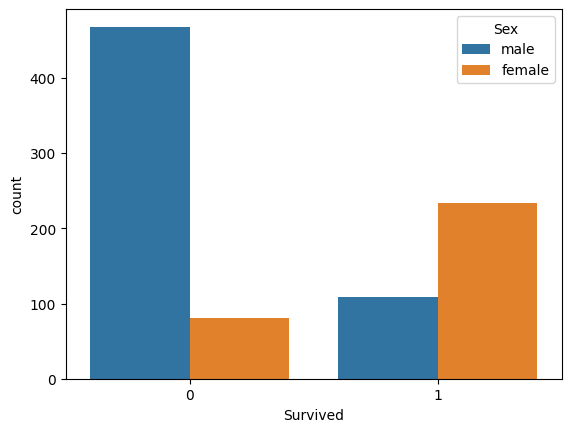

In [15]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

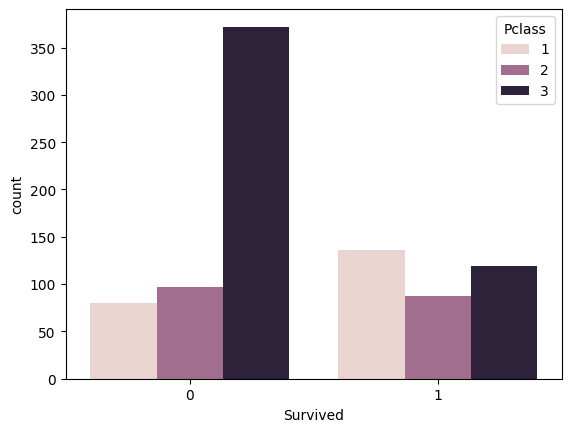

In [16]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Pclass', ylabel='Age'>

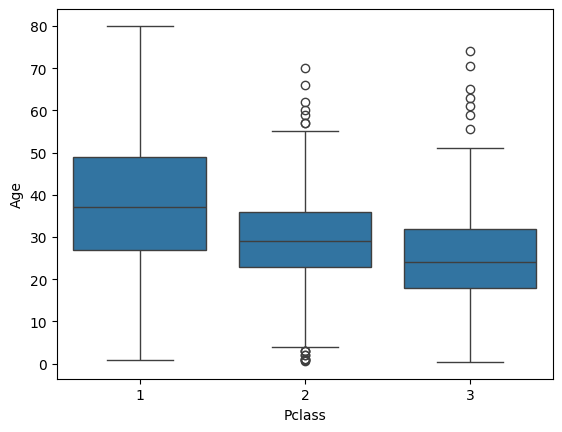

In [17]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

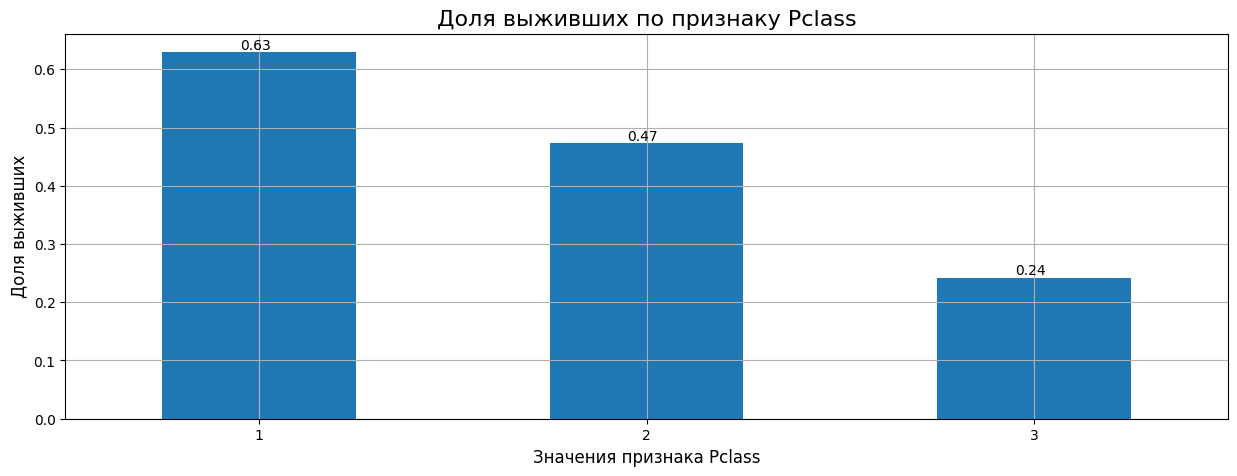

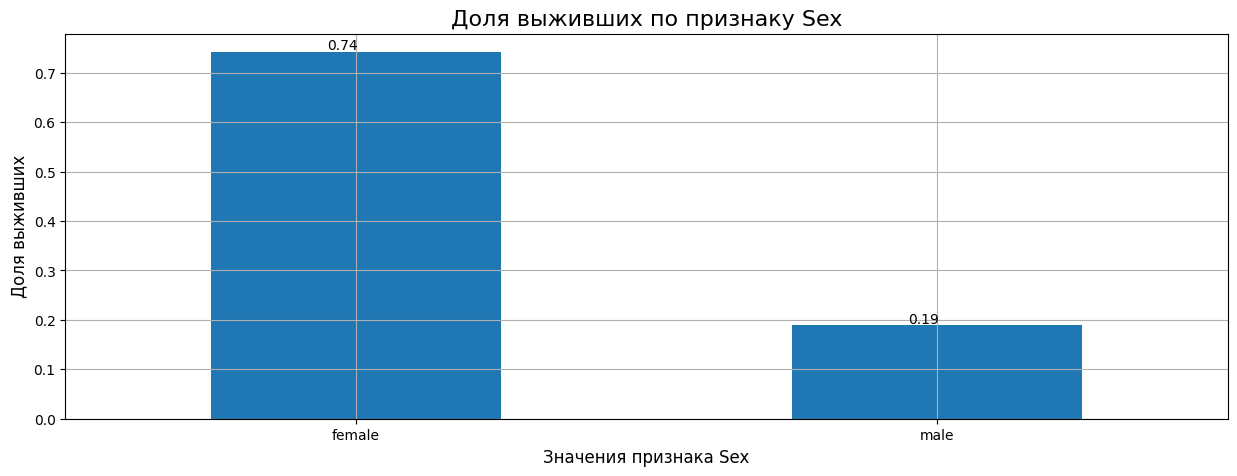

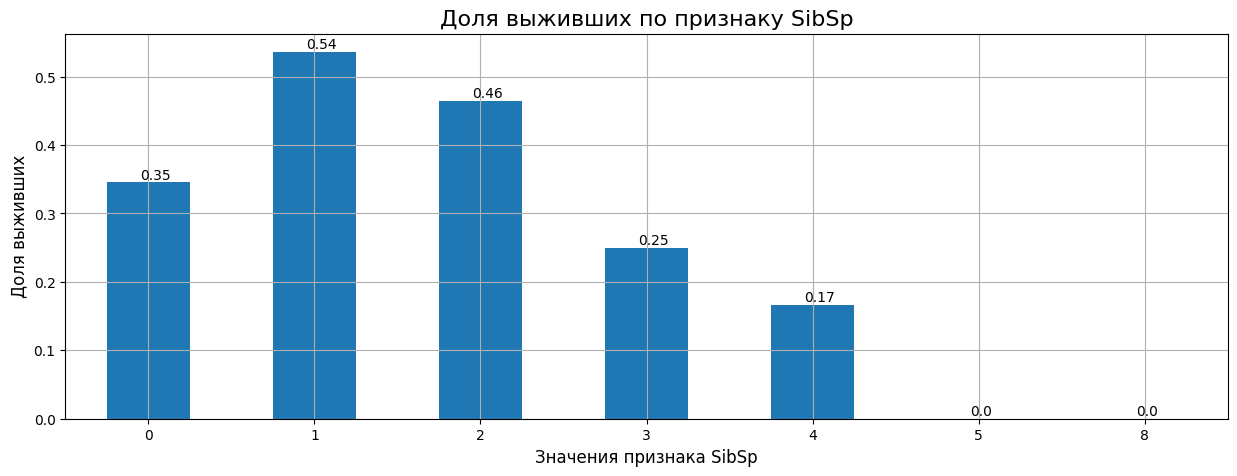

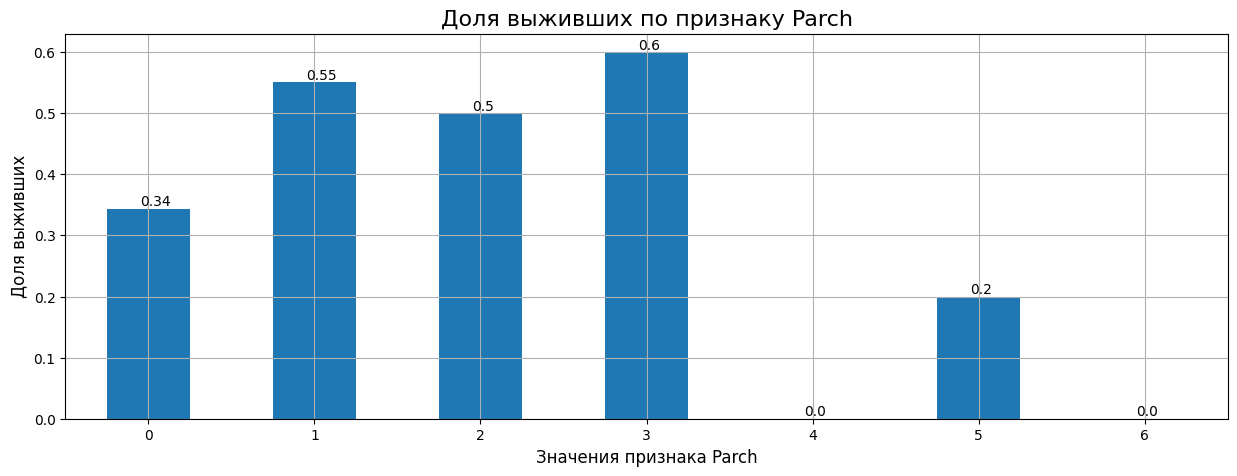

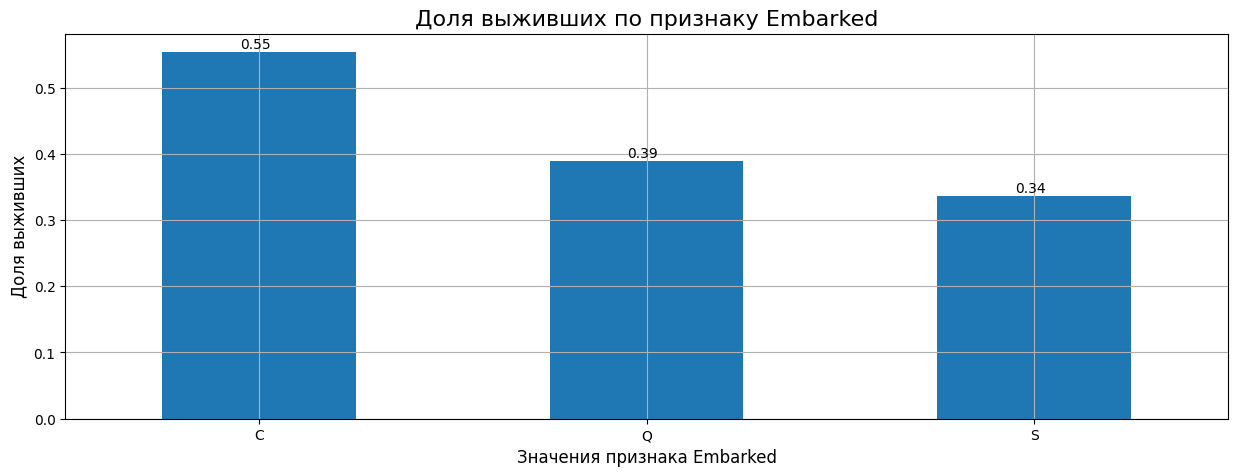

In [18]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax) 
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

In [19]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [20]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<Axes: >

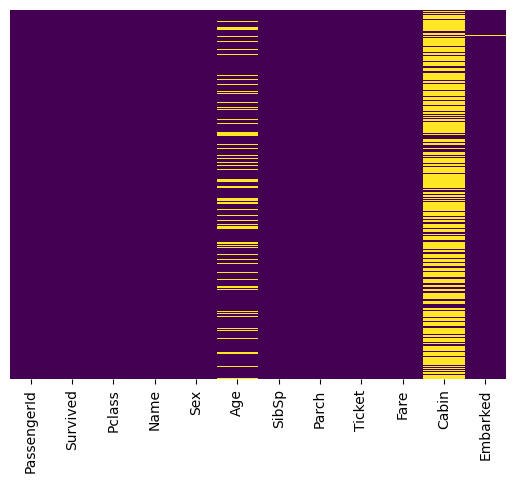

In [23]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

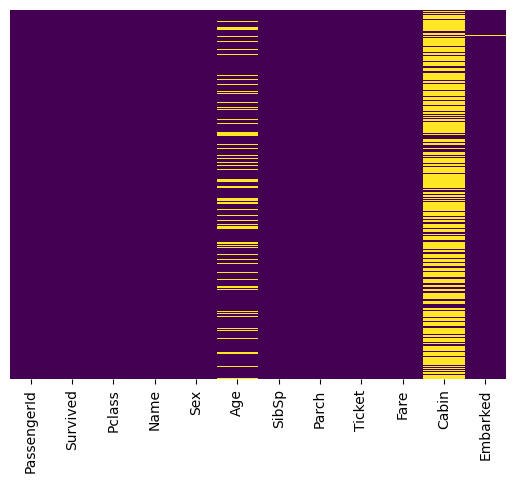

In [24]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [25]:
training_set.drop('Cabin', axis=1, inplace=True)

In [26]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

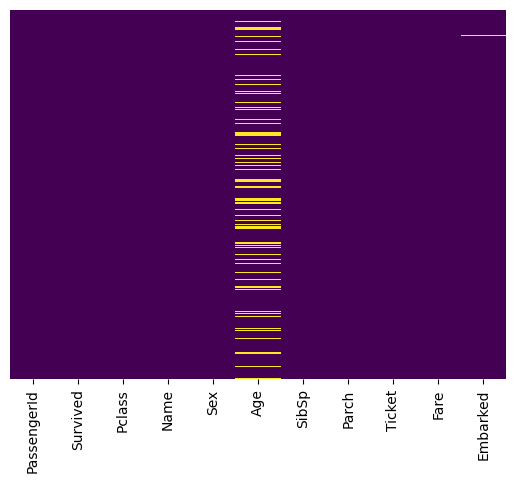

In [27]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [28]:
training_set.dropna(inplace=True)

In [29]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])
training_set['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [30]:
np.unique(cat_enc_le)  

array([0, 1])

In [31]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

In [32]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])  # Вызываем метод fit_transform, возвращает разреженную матрицу из библиотеки Scipy 

In [33]:
training_set.shape

(712, 11)

In [34]:
cat_enc_ohe.shape

(712, 3)

In [35]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


In [36]:
pd.get_dummies(training_set['Sex'], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


In [37]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)
sex

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


In [38]:
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

In [39]:
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [40]:
training_set = pd.concat([training_set, sex, embark], axis=1)

In [41]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [42]:
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# EXTRA TASKS
# 1

In [43]:
# classifier model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = training_set.drop('Survived', axis=1)
y = training_set['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        80
           1       0.85      0.65      0.74        63

    accuracy                           0.80       143
   macro avg       0.81      0.78      0.79       143
weighted avg       0.81      0.80      0.79       143



# 3 (2 is a dud)

In [44]:
total = len(training_set)
survived = training_set['Survived'].sum()
survival_rate = survived / total
print(f'Survival rate: {survival_rate:.2%}')
women_survived = training_set[training_set['male'] == 0]['Survived'].sum()
print(f'Women survivors out of total ({total}): {women_survived}')

Survival rate: 40.45%
Women survivors out of total (712): 195


# 4

In [45]:
pclass_counts = training_set['Pclass'].value_counts()
print(pclass_counts)

women_survived = training_set[training_set['Pclass'] == 3][training_set['male'] == 0]['Survived'].sum()
men_survived = training_set[training_set['Pclass'] == 3][training_set['male'] == 1]['Survived'].sum()
print(f'Women survivors in 3rd class: {women_survived}')
print(f'Men survivors in 3rd class: {men_survived}')

Pclass
3    355
1    184
2    173
Name: count, dtype: int64
Women survivors in 3rd class: 47
Men survivors in 3rd class: 38


/var/folders/4d/1d5j55lj60v45fpt1wk0gwm80000gn/T/ipykernel_2024/1510000767.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  women_survived = training_set[training_set['Pclass'] == 3][training_set['male'] == 0]['Survived'].sum()
/var/folders/4d/1d5j55lj60v45fpt1wk0gwm80000gn/T/ipykernel_2024/1510000767.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  men_survived = training_set[training_set['Pclass'] == 3][training_set['male'] == 1]['Survived'].sum()


# 5

In [46]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [47]:
ts_copy = training_set.drop(['Fare'], axis=1).copy()
ts_copy.head()

,Survived,Pclass,Age,SibSp,Parch,male,Q,S
0,0,3,22.0,1,0,True,False,True
1,1,1,38.0,1,0,False,False,False
2,1,3,26.0,0,0,False,False,True
3,1,1,35.0,1,0,False,False,True
4,0,3,35.0,0,0,True,False,True


# 6

0.09314251789411519


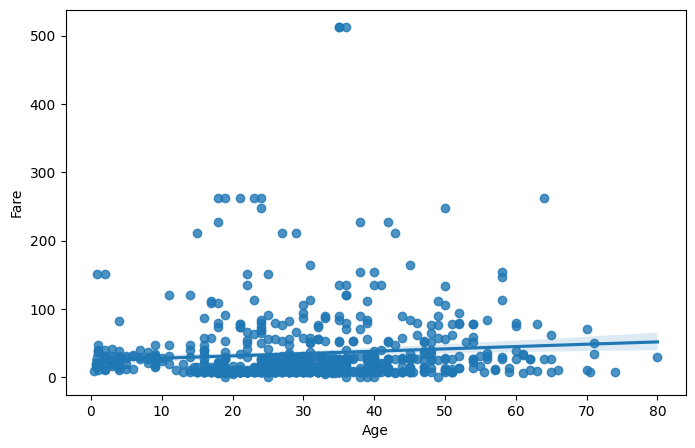

In [48]:
corr_value = training_set['Age'].corr(training_set['Fare'])
print(corr_value)
plt.figure(figsize=(8, 5))
sns.regplot(data=training_set, x='Age', y='Fare')
plt.show()

# 7

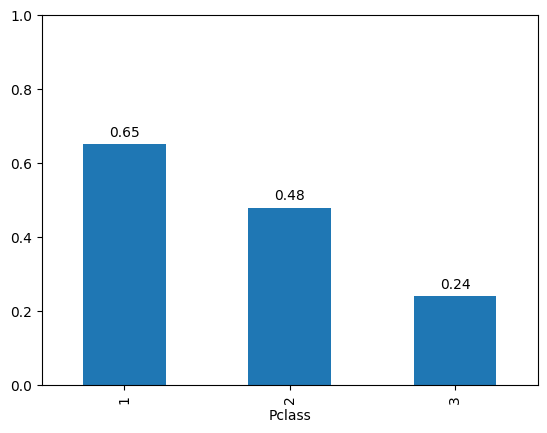

In [49]:
survivability_by_class = training_set.groupby('Pclass')['Survived'].mean().sort_index()

ax = survivability_by_class.plot(kind='bar')
ax.set_ylim(0, 1)
for i, v in enumerate(survivability_by_class.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

# 8

In [50]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


S
False    59.430515
True     27.476284
Name: Fare, dtype: float64


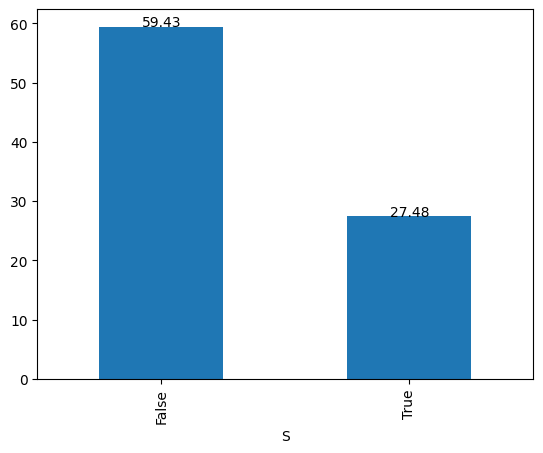

In [51]:
fare_per_port = training_set.groupby('S')['Fare'].mean().sort_index()
print(fare_per_port)
ax = fare_per_port.plot(kind='bar')
for i, v in enumerate(fare_per_port.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

In [52]:
fare_per_port = training_set.groupby('S')['Fare']
print(fare_per_port.min())
print(fare_per_port.max())
print(fare_per_port.mean())

S
False    4.0125
True     0.0000
Name: Fare, dtype: float64
S
False    512.3292
True     263.0000
Name: Fare, dtype: float64
S
False    59.430515
True     27.476284
Name: Fare, dtype: float64


# 9

S
False    Axes(0.125,0.11;0.775x0.77)
True     Axes(0.125,0.11;0.775x0.77)
Name: Fare, dtype: object

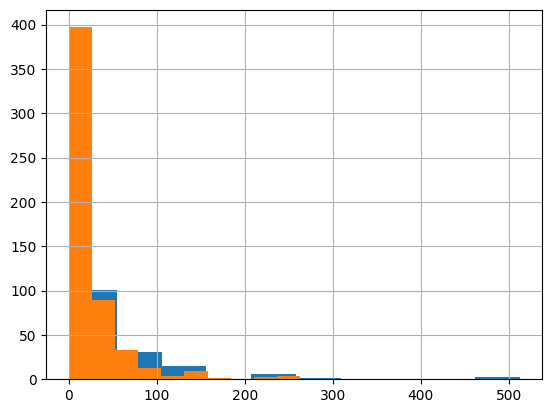

In [53]:
fare_per_port.hist()

# 10

In [54]:
print(len(training_set))
print(len(training_set[training_set['Survived'] == 1]))
# total on the titanic is really 2208, with a 68% survival rate
print('here:')
print(survival_rate)
# not that representative but okay for a small sample


712
288
here:
0.4044943820224719


# 11

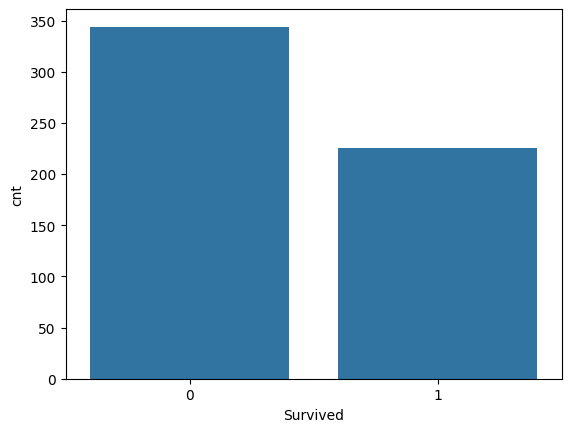

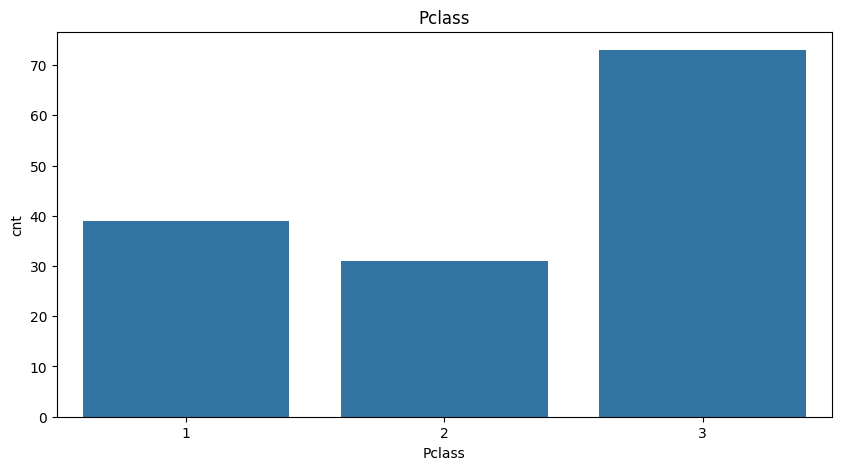

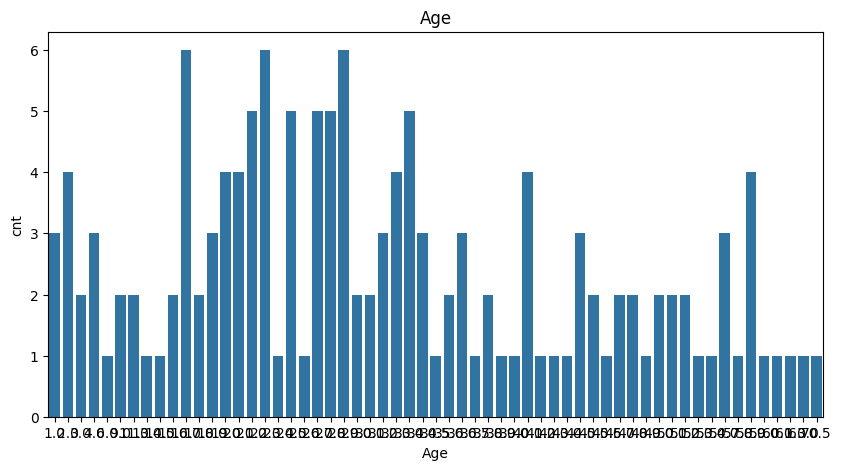

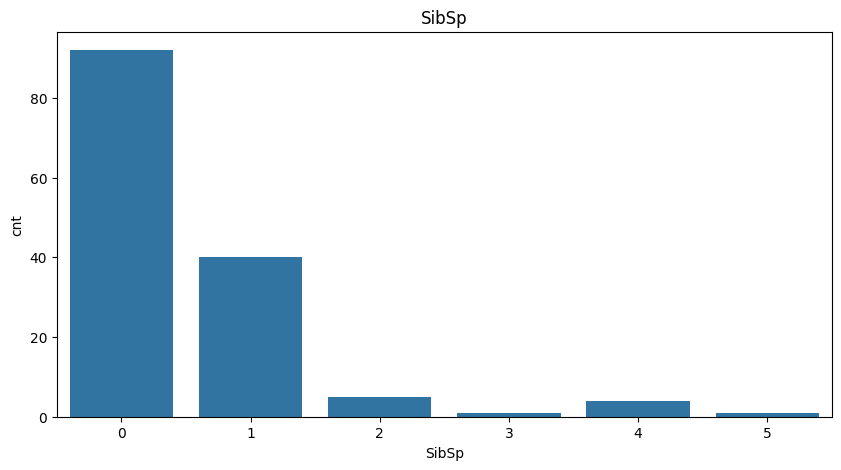

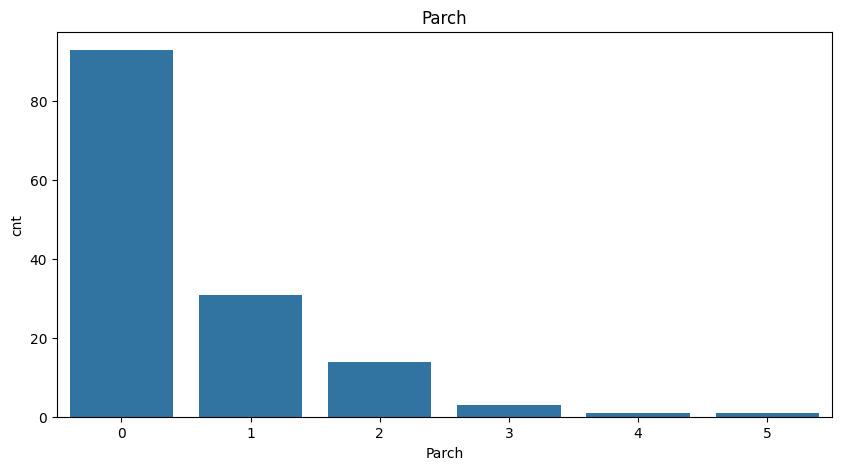

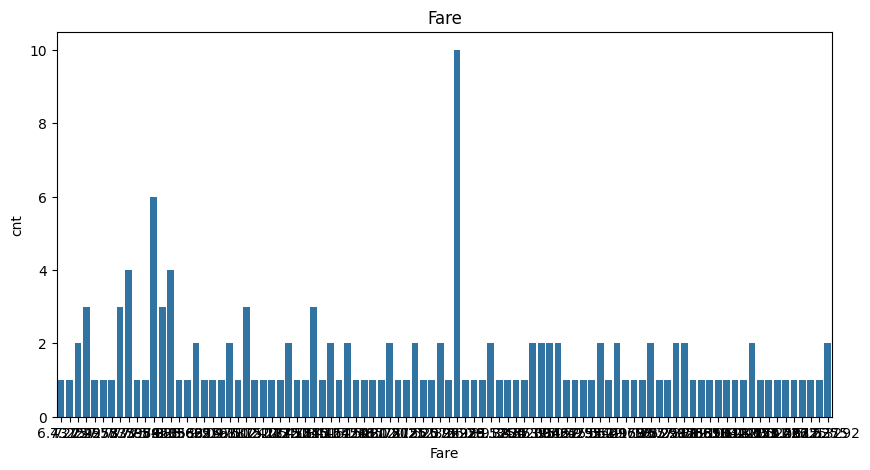

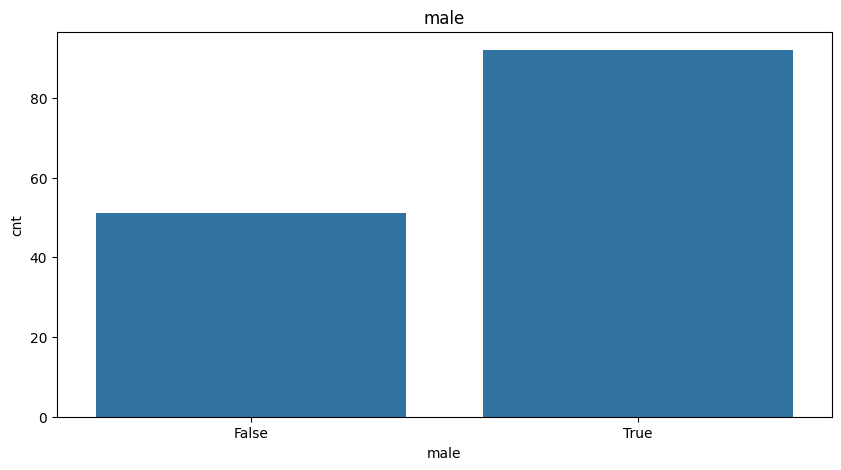

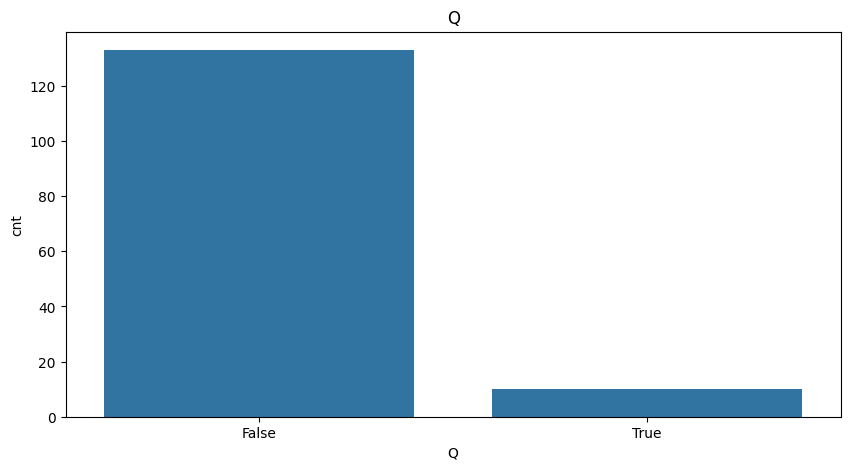

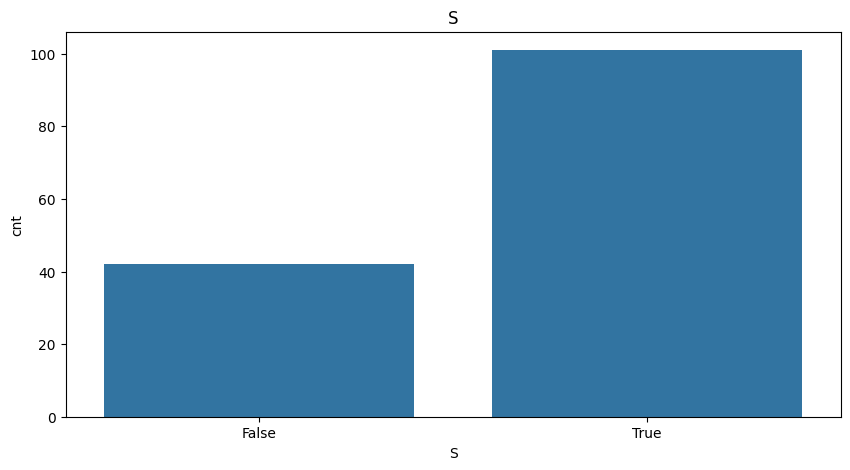

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sns.countplot(x=y_train)
plt.xlabel('Survived')
plt.ylabel('cnt')
plt.show()


for column in X_test.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=column, data=X_test)
    plt.title(f'{column}')
    plt.xlabel(column)
    plt.ylabel('cnt')
    plt.show()

# 12 - 17

In [56]:
target_col = 'Survived'
age_col = 'Age' 

In [57]:
X = training_set.drop(columns=[target_col])
y = training_set[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       122
           1       0.81      0.70      0.75        92

    accuracy                           0.80       214
   macro avg       0.80      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214



In [58]:
from sklearn.utils import resample
majority_class = training_set[training_set[target_col] == 0]
minority_class = training_set[training_set[target_col] == 1]

# undersampling
majority_undersampled = resample(majority_class, 
                                 replace=False,
                                 n_samples=len(minority_class),
                                 random_state=42)
df_undersampled = pd.concat([majority_undersampled, minority_class])

# oversampling
minority_oversampled = resample(minority_class, 
                                replace=True,
                                n_samples=len(majority_class),
                                random_state=42)
df_oversampled = pd.concat([majority_class, minority_oversampled])


In [59]:
X_over = df_oversampled.drop(columns=[target_col])
y_over = df_oversampled[target_col]

X_train_over, X_test_over, y_train_over, y_test_over = train_test_split(X_over, y_over, test_size=0.3, random_state=42)

model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_train_over, y_train_over)
y_pred_over = model_over.predict(X_test_over)
print(classification_report(y_test_over, y_pred_over))  # not much changed

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       122
           1       0.84      0.74      0.79       133

    accuracy                           0.79       255
   macro avg       0.80      0.79      0.79       255
weighted avg       0.80      0.79      0.79       255



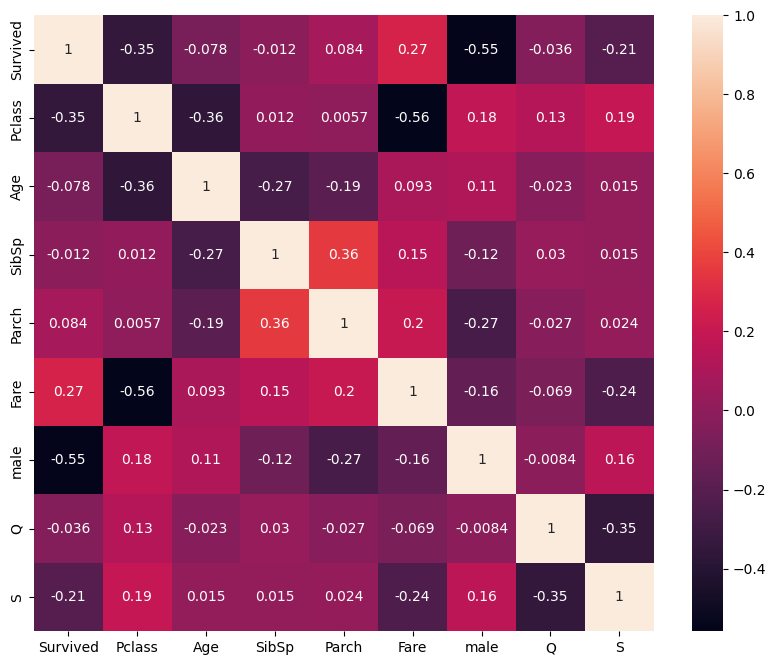

In [60]:
plt.figure(figsize=(10, 8))
corr_matrix = df_oversampled.corr()
sns.heatmap(corr_matrix, annot=True,)
plt.show()

In [61]:
def categorize_age(age):
    if age < 18:
        return 'child'
    elif age <= 65:
        return 'adult'
    else:
        return 'elderly'


training_set['age_category'] = training_set[age_col].apply(categorize_age)

df_encoded = pd.get_dummies(training_set, columns=['age_category'], drop_first=True)

In [62]:
X_age = df_encoded.drop(columns=[target_col])
y_age = df_encoded[target_col]

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_age, y_age, test_size=0.3, random_state=42)

In [63]:
model_age = LogisticRegression(max_iter=1000)
model_age.fit(X_train_age, y_train_age)
y_pred_age = model_age.predict(X_test_age)
print(classification_report(y_test_age, y_pred_age))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       122
           1       0.81      0.70      0.75        92

    accuracy                           0.80       214
   macro avg       0.80      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214



In [64]:
importance = pd.DataFrame({'Feature': X_train_age.columns, 'Coefficient': model_age.coef_[0]})
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)
print(importance)

                Feature  Coefficient  Abs_Coefficient
5                  male    -2.635326         2.635326
0                Pclass    -1.419514         1.419514
8    age_category_child     0.572058         0.572058
2                 SibSp    -0.343116         0.343116
7                     S    -0.197317         0.197317
6                     Q    -0.117792         0.117792
9  age_category_elderly    -0.093383         0.093383
1                   Age    -0.031840         0.031840
3                 Parch    -0.008201         0.008201
4                  Fare     0.000709         0.000709
